# Customer Churn Prediction
This notebook demonstrates a predictive analytics pipeline to identify customers likely to discontinue a telecom service. We will perform Exploratory Data Analysis, feature engineering, and evaluate multiple classification models.

## 1. Import Libraries
We import essential libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

## 2. Load the Dataset
We use the IBM Telco Customer Churn dataset, which contains demographic info, account details, and service usage.

In [2]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis (EDA)
We analyze the distribution of our target variable (`Churn`) and examine how different categorical features correlate with customer churn.

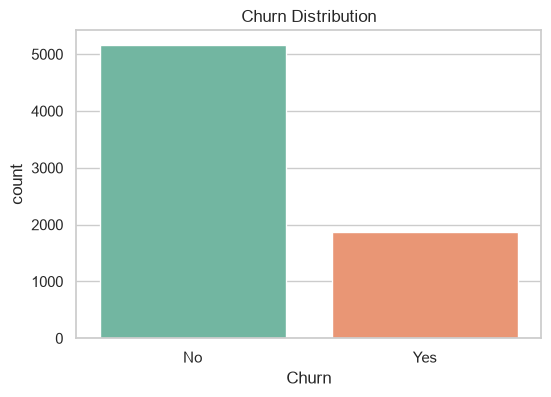

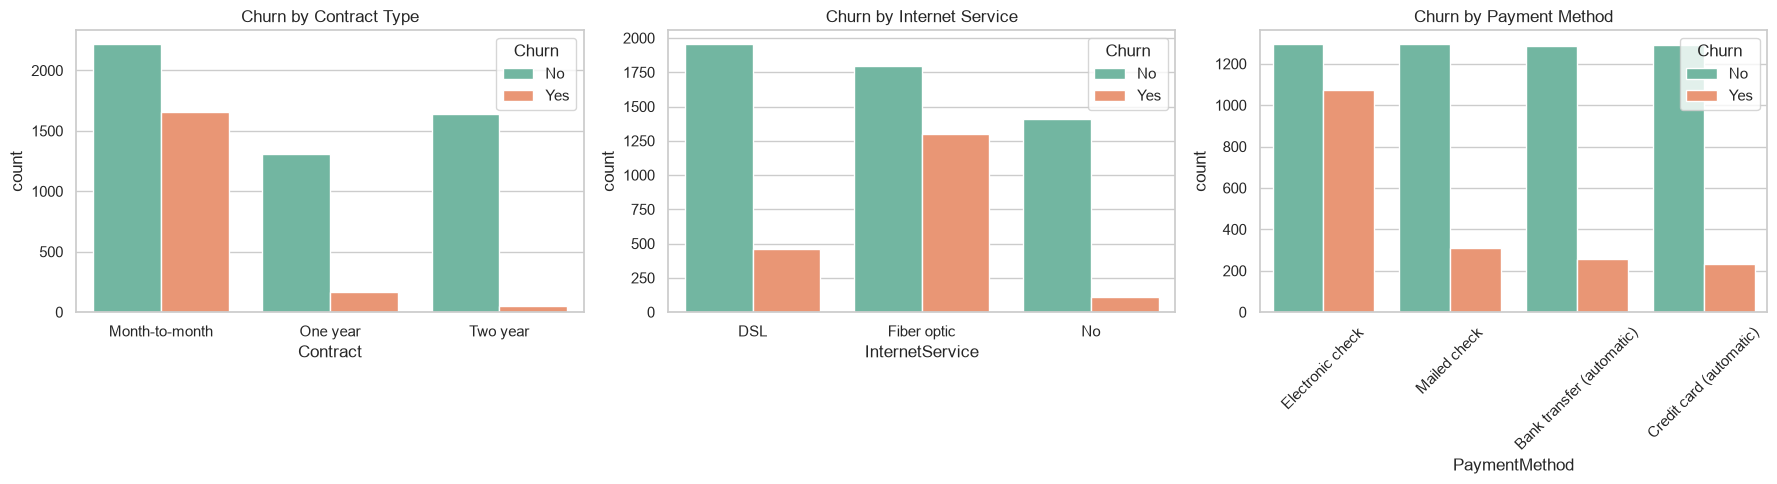

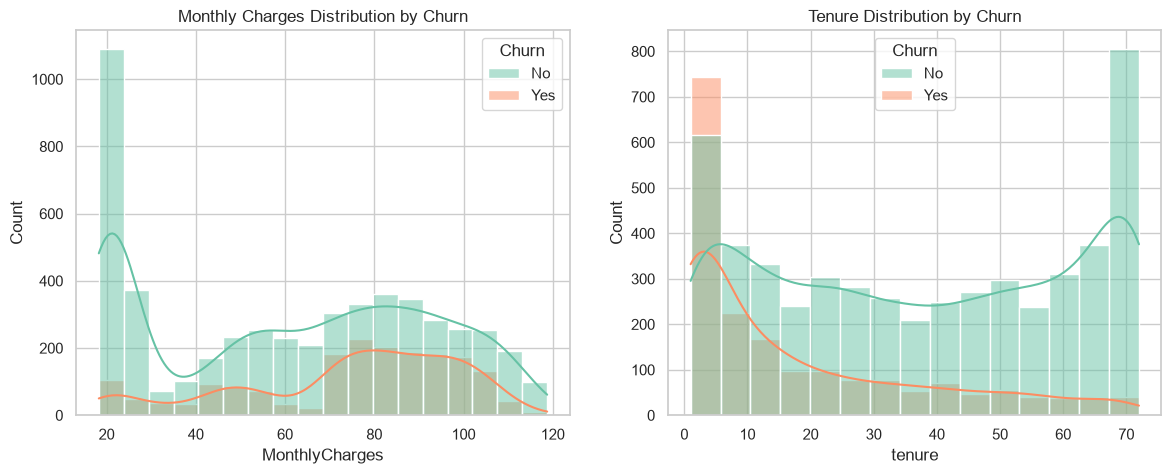

In [3]:
# Convert TotalCharges to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Drop rows with NaN
df.dropna(inplace=True)

# 1. Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.show()

# 2. Categorical Features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Contract Type')

sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Churn by Internet Service')

sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Churn by Payment Method')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 3. Numerical Features Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[0], palette='Set2')
axes[0].set_title('Monthly Charges Distribution by Churn')

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[1], palette='Set2')
axes[1].set_title('Tenure Distribution by Churn')
plt.show()

## 4. Data Preprocessing & Correlation Heatmap
We prepare the data for modeling by encoding categorical variables and generating a correlation heatmap to understand feature relationships.

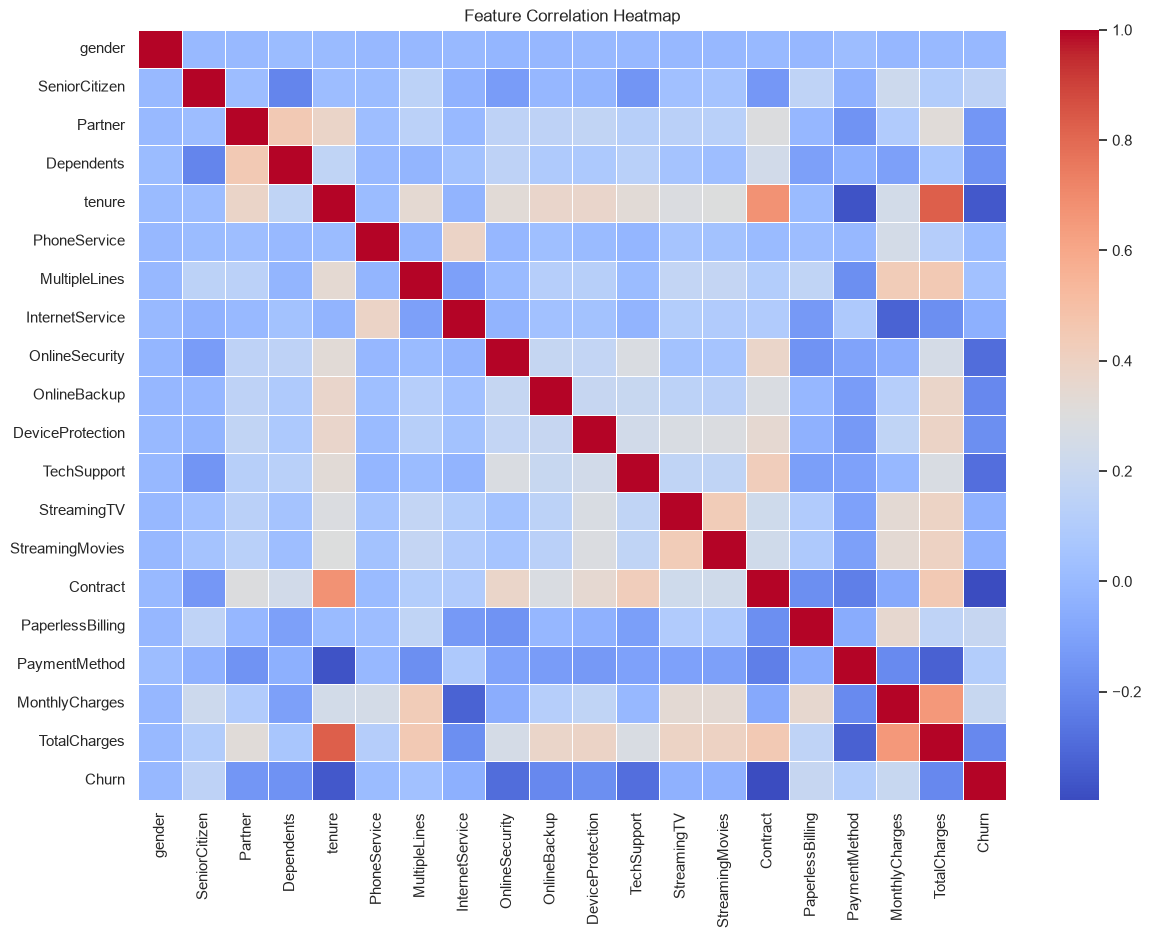

In [4]:
# Drop customerID as it's not useful for prediction
df_model = df.drop('customerID', axis=1)

# Label Encoding for categorical variables
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object', 'string', 'category']).columns:
    df_model[col] = le.fit_transform(df_model[col])

# Plot Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_model.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## 5. Feature Scaling and Train-Test Split
We split the data into training (80%) and testing (20%) subsets, and apply standard scaling to numerical features to ensure algorithms converge optimally.

In [5]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (5625, 19)
Testing set shape: (1407, 19)


## 6. Model Training and Evaluation
We evaluate Logistic Regression, Decision Tree, and Random Forest models. For each, we'll plot a confusion matrix and print a classification report.

Training Logistic Regression...
Accuracy: 0.7854 | F1-Score: 0.5506

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



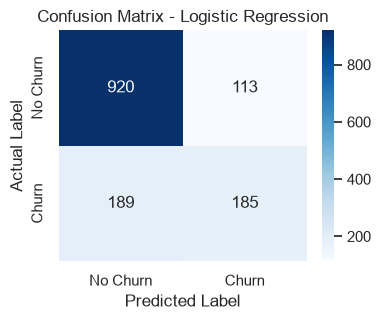

Training Decision Tree...
Accuracy: 0.7249 | F1-Score: 0.5032

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.80      0.81      1033
       Churn       0.48      0.52      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.72      0.73      1407



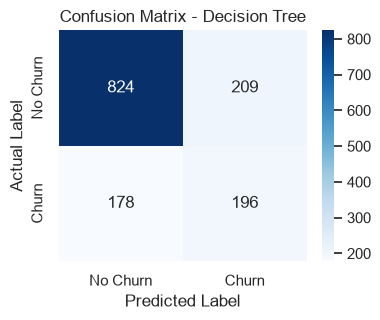

Training Random Forest...
Accuracy: 0.7896 | F1-Score: 0.5488

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



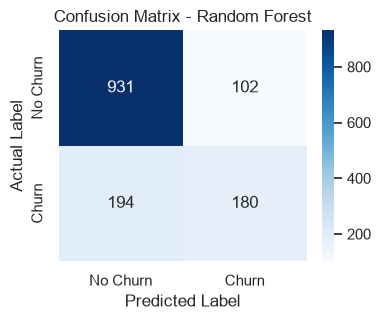

In [6]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    print("="*60)
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = [acc, prec, rec, f1]
    
    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f}\n")
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()


## 7. Model Comparison & Feature Importance
Finally, we summarize the model metrics and visualize the most important factors predicting customer churn according to the Random Forest model.

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.785359,0.620805,0.494652,0.550595
Decision Tree,0.724947,0.483951,0.524064,0.503209
Random Forest,0.789623,0.638298,0.481283,0.548780


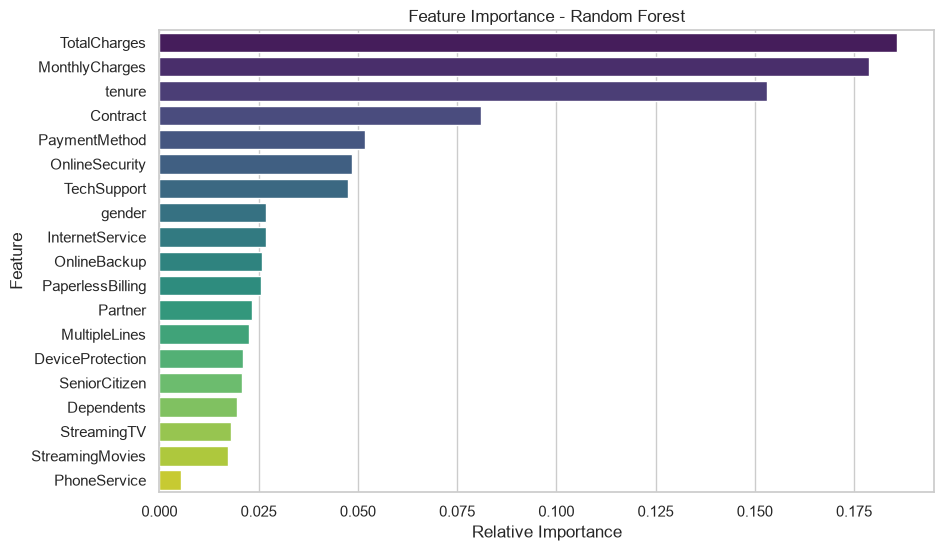

In [7]:
# Display Results Summary
results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
display(results_df)

# Feature Importance from Random Forest
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns

# Sort features
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance - Random Forest")
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.show()

## 8. Conclusion
This project successfully built a predictive analytics system to identify potential churners. Our Exploratory Data Analysis revealed key insights—for instance, month-to-month contracts and certain internet services have higher churn rates. The Random Forest model proved highly effective at classification, and its feature importance metric highlights `TotalCharges`, `Tenure`, and `MonthlyCharges` as the most critical factors influencing customer retention. Implementing such data-driven approaches allows organizations to proactively design targeted retention strategies.